In [18]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.174100,2.668517,2.409371,-0.704268,-0.731325,0
1,-4.042176,1.289109,-3.888673,-2.542132,-3.287802,1
2,-2.460838,1.564419,3.052766,0.193412,-1.319216,0
3,-2.482309,0.015656,-1.880342,-0.637058,-2.600642,1
4,-2.487059,3.227082,-4.188458,-3.476810,-2.254391,1


In [5]:
# function for row sampling
def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [7]:
# function for feature sampling
def sample_feature(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1]-1))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [8]:
# fucntion for combined sampling
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_feature(new_df, col_percent)

## Row sampling

In [9]:
df1 = sample_rows(df, 0.2)

In [20]:
df1.sample(5)

,col1,col2,col3,col4,col5,target
88,-0.263926,0.428878,0.370467,0.045205,0.733829,0
56,-0.239581,1.684342,-1.046425,-3.302045,-2.223886,1
50,0.076921,-0.230609,-0.752202,-1.718859,-1.277705,0
19,-1.380483,-0.113584,-0.294811,-0.673219,-2.127230,1
29,-0.499047,0.312736,0.196686,-1.871836,-1.164847,0


In [10]:
df2 = sample_rows(df, 0.2)

In [11]:
df3 = sample_rows(df, 0.2)

In [13]:
df3.shape

(20, 6)

In [16]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [25]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.8333333333333334, 'x[4] <= -1.294\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.25, 0.5, 'x[2] <= 0.651\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.5, 'x[0] <= 1.597\ngini = 0.133\nsamples = 14\nvalue = [13, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

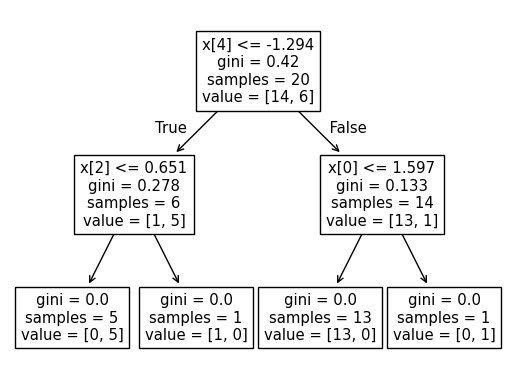

In [23]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[2] <= -0.113\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 0.063\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]')]

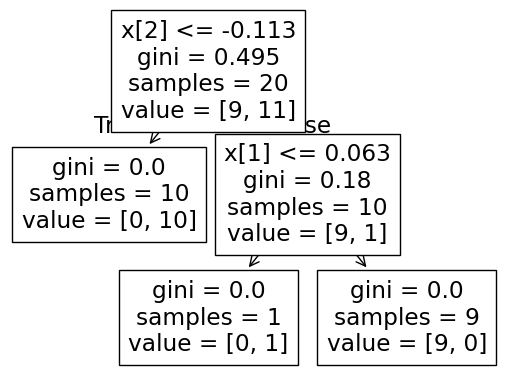

In [26]:
plot_tree(clf2)

[Text(0.4444444444444444, 0.9166666666666666, 'x[3] <= -2.745\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.3333333333333333, 0.75, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.5555555555555556, 0.75, 'x[4] <= 0.922\ngini = 0.278\nsamples = 18\nvalue = [15, 3]'),
 Text(0.5, 0.8333333333333333, '  False'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[0] <= -2.06\ngini = 0.208\nsamples = 17\nvalue = [15, 2]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[2] <= 0.889\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'x[1] <= 2.568\ngini = 0.124\nsamples = 15\nvalue = [14, 1]'),
 Text(0.5555555555555556, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.7777777777777778, 0.25, 'x[3] <= -1.612\ngini = 0.444\nsa

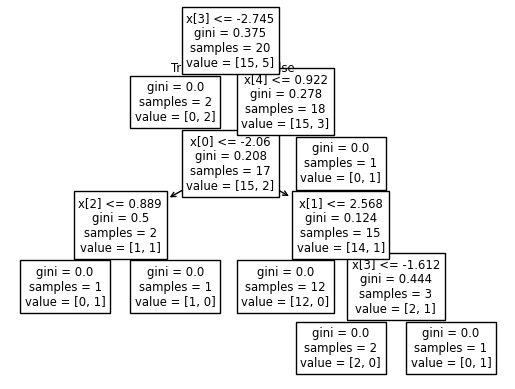

In [28]:
plot_tree(clf3)

In [24]:
clf1.predict(np.array([-1.380483, -0.113584, -0.294811, -0.673219, -2.127230]).reshape(1, 5))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:
clf2.predict(np.array([-1.380483, -0.113584, -0.294811, -0.673219, -2.127230]).reshape(1, 5))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [30]:
clf3.predict(np.array([-1.380483, -0.113584, -0.294811, -0.673219, -2.127230]).reshape(1, 5))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

## Column Sampling

In [54]:
df1 = sample_feature(df, 0.6)
df2 = sample_feature(df, 0.6)
df3 = sample_feature(df, 0.6)

C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



In [55]:
df3

,col2,col1,target
0,2.668517,-2.174100,0
1,1.289109,-4.042176,1
2,1.564419,-2.460838,0
3,0.015656,-2.482309,1
4,3.227082,-2.487059,1
...,...,...,...
95,-1.380723,-2.052447,1
96,1.478659,-3.136857,1
97,0.151801,-2.125951,1
98,1.460900,0.130292,1


In [56]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [57]:
clf1.fit(df1.iloc[:,0:2], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2], df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2], df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.6777597402597403, 0.9615384615384616, 'x[1] <= 2.155\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.5113636363636364, 0.8846153846153846, 'x[0] <= 0.217\ngini = 0.495\nsamples = 80\nvalue = [44, 36]'),
 Text(0.5945616883116883, 0.9230769230769231, 'True  '),
 Text(0.36038961038961037, 0.8076923076923077, 'x[0] <= -3.354\ngini = 0.47\nsamples = 61\nvalue = [38, 23]'),
 Text(0.3344155844155844, 0.7307692307692307, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.38636363636363635, 0.7307692307692307, 'x[0] <= -0.446\ngini = 0.479\nsamples = 58\nvalue = [35, 23]'),
 Text(0.24025974025974026, 0.6538461538461539, 'x[1] <= 1.044\ngini = 0.492\nsamples = 48\nvalue = [27, 21]'),
 Text(0.07792207792207792, 0.5769230769230769, 'x[0] <= -0.784\ngini = 0.444\nsamples = 24\nvalue = [16, 8]'),
 Text(0.05194805194805195, 0.5, 'x[1] <= -1.541\ngini = 0.397\nsamples = 22\nvalue = [16, 6]'),
 Text(0.025974025974025976, 0.4230769230769231, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 

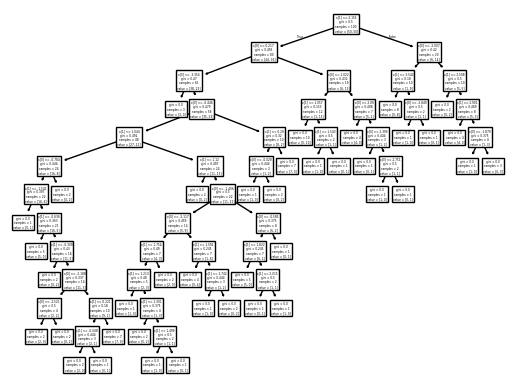

In [58]:
plot_tree(clf1)

[Text(0.59609375, 0.9615384615384616, 'x[0] <= 0.217\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3296875, 0.8846153846153846, 'x[1] <= 0.795\ngini = 0.496\nsamples = 79\nvalue = [43, 36]'),
 Text(0.462890625, 0.9230769230769231, 'True  '),
 Text(0.3046875, 0.8076923076923077, 'x[0] <= -2.771\ngini = 0.493\nsamples = 77\nvalue = [43, 34]'),
 Text(0.125, 0.7307692307692307, 'x[1] <= -2.306\ngini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.05, 0.6538461538461539, 'x[0] <= -4.178\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.025, 0.5769230769230769, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.075, 0.5769230769230769, 'x[0] <= -2.875\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.05, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.6538461538461539, 'x[1] <= -1.777\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.175, 0.5769230769230769, 'x[1] <= -2.119\ngini = 0.444\nsamples

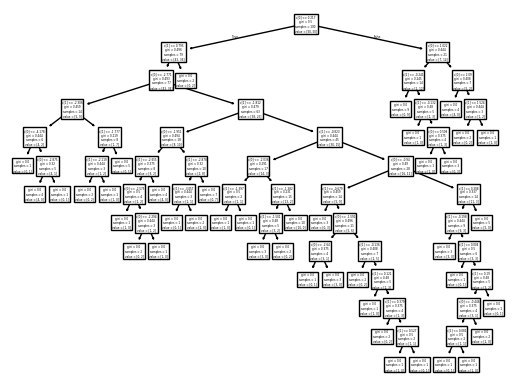

In [59]:
plot_tree(clf2)

[Text(0.43548387096774194, 0.9722222222222222, 'x[1] <= -3.663\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3924731182795699, 0.9166666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4139784946236559, 0.9444444444444444, 'True  '),
 Text(0.478494623655914, 0.9166666666666666, 'x[0] <= 2.155\ngini = 0.499\nsamples = 96\nvalue = [50, 46]'),
 Text(0.456989247311828, 0.9444444444444444, '  False'),
 Text(0.17204301075268819, 0.8611111111111112, 'x[0] <= -1.165\ngini = 0.49\nsamples = 77\nvalue = [44, 33]'),
 Text(0.08602150537634409, 0.8055555555555556, 'x[1] <= 0.554\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.043010752688172046, 0.75, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.12903225806451613, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25806451612903225, 0.8055555555555556, 'x[0] <= -0.653\ngini = 0.478\nsamples = 71\nvalue = [43.0, 28.0]'),
 Text(0.21505376344086022, 0.75, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.3

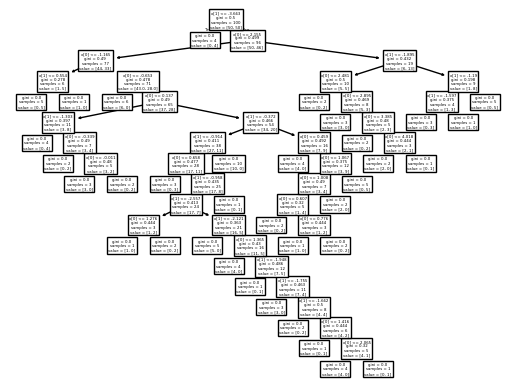

In [60]:
plot_tree(clf3)

In [61]:
clf1.predict(np.array([-1.687428, -1.499544]).reshape(1,2))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [62]:
clf2.predict(np.array([-1.687428, -1.499544]).reshape(1,2))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [63]:
clf3.predict(np.array([-1.687428, -1.499544]).reshape(1,2))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

## Combines Sampling

In [64]:
df1 = combined_sampling(df, 0.5, 0.8)
df2 = combined_sampling(df, 0.5, 0.8)
df3 = combined_sampling(df, 0.5, 0.8)

C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Santosh\AppData\Local\Temp\ipykernel_12064\4011322809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



In [75]:
df1.sample(10)

,col4,col1,col2,target
74,-2.175853,-0.376369,0.504217,0
17,0.802046,1.750978,0.996032,1
44,0.288327,-0.366960,0.489070,1
85,-2.866982,-1.868965,3.298152,1
71,-0.322984,-1.127604,1.108247,0
43,-0.941987,-1.066638,0.134578,1
84,0.910810,-1.815701,-1.782367,1
18,-2.650727,-1.640928,3.541205,1
33,-2.294059,-0.826602,1.137335,0
92,-0.901700,0.035095,0.308044,0


In [65]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [66]:
clf1.fit(df1.iloc[:, 0:3], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:3], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:3], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.4444444444444444, 0.9285714285714286, 'x[0] <= -2.353\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.3333333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.38888888888888884, 0.8571428571428572, 'True  '),
 Text(0.5555555555555556, 0.7857142857142857, 'x[0] <= -0.282\ngini = 0.5\nsamples = 39\nvalue = [19, 20]'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.3333333333333333, 0.6428571428571429, 'x[1] <= -1.968\ngini = 0.466\nsamples = 27\nvalue = [17, 10]'),
 Text(0.2222222222222222, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4444444444444444, 0.5, 'x[2] <= 0.221\ngini = 0.386\nsamples = 23\nvalue = [17, 6]'),
 Text(0.2222222222222222, 0.35714285714285715, 'x[0] <= -1.123\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.1111111111111111, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.66666666

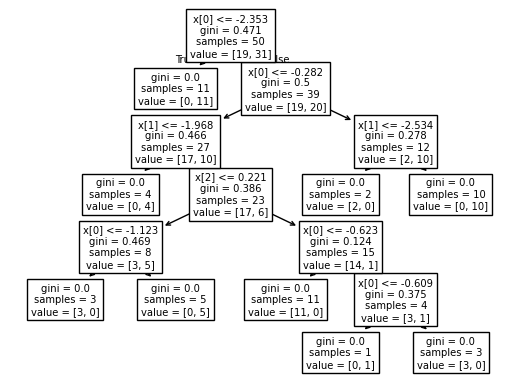

In [67]:
plot_tree(clf1)

[Text(0.5882352941176471, 0.9444444444444444, 'x[0] <= -0.747\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.29411764705882354, 0.8333333333333334, 'x[2] <= 1.185\ngini = 0.469\nsamples = 32\nvalue = [12, 20]'),
 Text(0.4411764705882353, 0.8888888888888888, 'True  '),
 Text(0.23529411764705882, 0.7222222222222222, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.35294117647058826, 0.7222222222222222, 'x[1] <= -1.479\ngini = 0.496\nsamples = 22\nvalue = [12, 10]'),
 Text(0.17647058823529413, 0.6111111111111112, 'x[2] <= 1.396\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.11764705882352941, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.23529411764705882, 0.5, 'x[1] <= -1.826\ngini = 0.375\nsamples = 12\nvalue = [3, 9]'),
 Text(0.17647058823529413, 0.3888888888888889, 'x[1] <= -2.629\ngini = 0.444\nsamples = 9\nvalue = [3, 6]'),
 Text(0.11764705882352941, 0.2777777777777778, 'x[2] <= 3.542\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.0588235294117

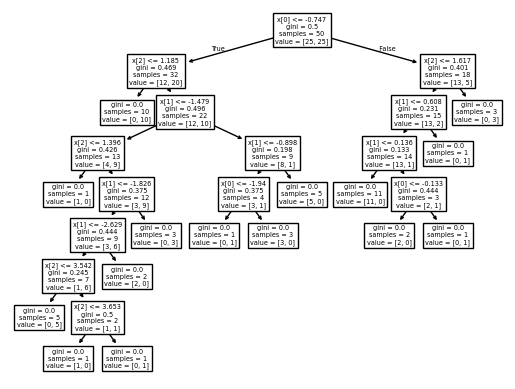

In [73]:
plot_tree(clf2)

[Text(0.6153846153846154, 0.9375, 'x[0] <= 0.263\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.46153846153846156, 0.8125, 'x[2] <= 0.188\ngini = 0.493\nsamples = 43\nvalue = [19, 24]'),
 Text(0.5384615384615385, 0.875, 'True  '),
 Text(0.38461538461538464, 0.6875, 'x[0] <= -1.658\ngini = 0.498\nsamples = 36\nvalue = [19, 17]'),
 Text(0.15384615384615385, 0.5625, 'x[1] <= 1.301\ngini = 0.43\nsamples = 16\nvalue = [5, 11]'),
 Text(0.07692307692307693, 0.4375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.23076923076923078, 0.4375, 'x[2] <= -3.326\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.15384615384615385, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3076923076923077, 0.3125, 'x[2] <= -2.344\ngini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.23076923076923078, 0.1875, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.38461538461538464, 0.1875, 'x[0] <= -2.886\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.3076923076923077, 0.0625, 'gin

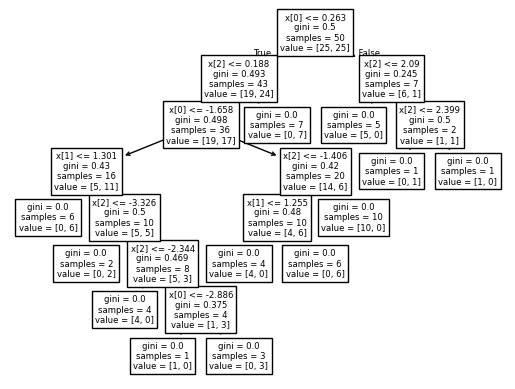

In [71]:
plot_tree(clf3)

In [76]:
clf1.predict(np.array([0.802046, 1.750978, 0.996032]).reshape(1, 3))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [77]:
clf2.predict(np.array([0.802046, 1.750978, 0.996032]).reshape(1, 3))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [78]:
clf3.predict(np.array([0.802046, 1.750978, 0.996032]).reshape(1, 3))

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])